<a href="https://colab.research.google.com/github/Mytros/DS_ML_homework/blob/main/HW_4_3_LSTM_%D0%B4%D0%BB%D1%8F_%D0%BF%D1%80%D0%BE%D0%B3%D0%BD%D0%BE%D0%B7%D1%83%D0%B2%D0%B0%D0%BD%D0%BD%D1%8F_%D1%87%D0%B0%D1%81%D0%BE%D0%B2%D0%B8%D1%85_%D1%80%D1%8F%D0%B4%D1%96%D0%B2_Dmytro_Koval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Давайте подивимося, як LSTM можна використовувати для побудови нейронної мережі прогнозування часових.

Будемо працювати з задачею прогнозування кількості пасажирів міжнародних авіаліній. З цим набором даних ми вже працювали в лекції "Time Series Analysis" і ви зможете порівняти результати :)

Задача полягає в тому, щоб за заданими роком і місяцем передбачити кількість пасажирів міжнародних авіаліній в одиницях виміру 1,000. Дані охоплюють період з січня 1949 року по грудень 1960 року, тобто 12 років, зі 144 спостереженнями.

Це регресійна задача. Тобто, знаючи кількість пасажирів (в тисячах) за останні місяці, можна передбачити, якою буде кількість пасажирів у наступному місяці. Набір даних має лише одну характеристику: "Кількість пасажирів" - `Passengers`.

Далі вже наведений код для читання даних, але нам їх ще треба буде трошки обробити.

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

# Завантаження даних
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)
df.set_index('Month', inplace=True)
display(df.head())

,Passengers
Month,
1949-01,112
1949-02,118
1949-03,132
1949-04,129
1949-05,121


**Завдання 1.** Створіть змінну типу `numpy.ndarray`, яка містить значення кількості пасажирів в форматі `float32`. Такий формат даних нам треба для тренування нейромережі.

In [2]:
data = df['Passengers'].values.astype('float32')
data[:5]



array([112., 118., 132., 129., 121.], dtype=float32)

Очікуваний результат:
```array([112., 118., 132., 129., 121.], dtype=float32)```

**Завдання 2**. Розбийте дані на тренувальні і валідаційні у співвідношенні 67% йде у тренування, 33 - у валідацію. Памʼятаємо, що ми працюємо з tim series, відповідно, навчаємось на давніших, валідуємось - на новіших.

In [3]:
# chronological split
n = len(data)
split_idx = int(n * 0.67)          # 67% of the data for training

train = data[:split_idx]      # older for training (first 96)
test   = data[split_idx:]      # newer for validation (last 48)

print(len(train), len(test))
print(train[:3], '...', train[-3:])
print(test[:3], '...', test[-3:])


96 48
[112. 118. 132.] ... [306. 271. 306.]
[315. 301. 356.] ... [461. 390. 432.]


**Завдання 3**.

Реалізуйте функцію `create_dataset`, яка перетворить одномірний часовий ряд (набір даних) у формат, придатний для тренування нейромережі.

Функція повинна приймати два аргументи:
- `dataset` — numpy-масив часового ряду,
- `lookback` — кількість попередніх кроків, які використовуватимуться для передбачення.

Функція повинна повернути два **тензори** PyTorch:
- `X` — набір ознак (вікно попередніх значень),
- `y` — цільові значення (наступні після вікна кроки).

Дані ми будемо подавати моделі в наступному форматі:
`
tensor([[112.],
        [118.],
        [132.],
        [129.],
        [121.]])
`
Відповідно першою розмірністю буде йти розмір вхідного батча, а другою - розмір вхіднизх даних і в нас це 1, бо лише одне значення на вході щоразу.

Після виконання завдання запустіть код нижче. Ми будемо передбачати на основі кількості пасажирів в попередній день кількість пасажирів в наступний, тому `lookback == 1`.

In [4]:
import torch

# convert time series into supervised learning format
def create_dataset(dataset, lookback):
    X, y = [], []
    for i in range(len(dataset) - lookback):
        # take previous lookback values as features
        X.append(dataset[i:(i + lookback)])
        # take the next value as the target
        y.append(dataset[i + lookback])
    # convert to PyTorch tensors
    X = torch.tensor(X, dtype=torch.float32).view(-1, lookback)
    y = torch.tensor(y, dtype=torch.float32).view(-1, 1)
    return X, y


In [5]:
lookback = 1
X_train, y_train = create_dataset(train, lookback=lookback)
X_test, y_test = create_dataset(test, lookback=lookback)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([95, 1]) torch.Size([95, 1])
torch.Size([47, 1]) torch.Size([47, 1])


/tmp/ipython-input-1660209259.py:12: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  X = torch.tensor(X, dtype=torch.float32).view(-1, lookback)


Очікуваний результат:
```
torch.Size([95, 1]) torch.Size([95, 1])
torch.Size([47, 1]) torch.Size([47, 1])
```

**Завдання 4**.

Зверніть увагу на розмірності в попередньому завданні. Ми
З допомогою модуля `torch.nn` опишіть клас `AirModel`, який є нейронною мережею для прогнозування кількості пасажирів за допомогою LSTM.

1. **Конструктор класу** повинен приймати параметри `hidden_size`, `num_layers` та ініціювати шари:
   - LSTM-шар з наступними параметрами:
     - `input_size` — кожна точка часового ряду є окремим входом,,
     - `hidden_size` — заданий в конструкторі класу мережі,
     - `num_layers=1` — кількість шарів LSTM, задана в конструкторі мережі,
     - `batch_first=True` — визначає, що першим виміром є розмір батчу.
   - Лінійний шар (`nn.Linear`) для перетворення виходу LSTM на прогноз однієї точки.

2. **Метод forward** повинен виконувати наступні дії:
   - Передати вхідний тензор через LSTM-шар і отримати виходи (ігноруючи приховані стани).
   - Пропустити вихід LSTM через лінійний шар для отримання остаточного прогнозу.

Створіть об'єкт класу `AirModel` зі значеннями параметрів `hidden_size=50`, `num_layers=1` і протестуйте роботу моделі на вхідному тензорі `tensor([[112.]])`. На цьому етапі ми маємо переконатись, що модель здатна генерувати передбачення з рандомно ініційованими вагами.

In [6]:
import torch
import torch.nn as nn

# LSTM model for univariate time series
class AirModel(nn.Module):
    def __init__(self, hidden_size=50, num_layers=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # input_size = 1 -> single feature 'Passengers'
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        # Map the last hidden output to a single scalar prediction
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        """
        x shape can be:
          - (batch, 1)          when lookback == 1
          - (batch, seq_len, 1) when lookback > 1
        We normalize to (batch, seq_len, 1).
        """
        if x.dim() == 2:               # (batch, 1) -> (batch, 1, 1)
            x = x.unsqueeze(1)
        # x now is (batch, seq_len, 1)
        out, _ = self.lstm(x)          # out: (batch, seq_len, hidden_size)
        last = out[:, -1, :]           # take last timestep: (batch, hidden_size)
        pred = self.fc(last)           # (batch, 1)
        return pred

# Instantiate and quick sanity check
model = AirModel(hidden_size=50, num_layers=1)

# Test input (batch=1, feature=1), dtype float32
test_x = torch.tensor([[112.0]], dtype=torch.float32)
with torch.no_grad():
    y_hat = model(test_x)
print(y_hat.shape, y_hat)


torch.Size([1, 1]) tensor([[0.3839]])


**Завдання 5**.

Створіть об'єкт DataLoader для завантаження даних, використовуючи тренувальні вибірки `X_train` та `y_train`. Ваш DataLoader повинен виконувати наступні вимоги:

1. Використовувати клас `TensorDataset`, щоб об'єднати тензори ознак `X_train` і цільових значень `y_train`.
2. Дані повинні завантажуватися невеликими батчами розміром 8 за допомогою параметра `batch_size`.
3. Використовувати параметр `shuffle=True`, щоб дані перемішувалися перед кожною епохою тренування.


In [7]:
from torch.utils.data import TensorDataset, DataLoader

# Combine features and targets into one dataset
train_dataset = TensorDataset(X_train, y_train)

# Create DataLoader with batch size 8 and shuffling
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

# Quick check
for xb, yb in train_loader:
    print(xb.shape, yb.shape)
    break


torch.Size([8, 1]) torch.Size([8, 1])


**Завдання 6**.

1. Реалізуйте навчання нейронної мережі `AirModel` для прогнозування часових рядів, використовуючи Adam-оптимізатор та функцію втрат MSE (середньоквадратичну похибку).
2. Створіть цикл тренування для 2000 епох, у якому на кожній епосі:
   - Виконуйте крок тренування моделі (прямий прохід, обчислення похибки, зворотний прохід і оновлення ваг).
   - Підраховуйте середню похибку на кожному батчі даних і зберігайте її у списку `losses`.
3. Раз на 100 епох проводьте валідацію моделі:
   - Перевіряйте модель на тренувальних та тестових даних без оновлення ваг.
   - Обчислюйте корінь середньоквадратичної похибки (RMSE) для тренувальної та тестової вибірок і виводьте результати на екран.
   
**Примітка:**
- Використовуйте вже створений `DataLoader` для отримання батчів даних.
- Валідацію виконуйте в режимі `eval()`, вимикаючи обчислення градієнтів з `torch.no_grad()`.

**Приклад виходу:**
```
Epoch 0: train RMSE 12.3456, test RMSE 15.6789
Epoch 100: train RMSE 9.8765, test RMSE 12.3456
...
```

In [8]:
import torch
import torch.nn as nn

# Training with Adam + MSE, 2000 epochs, periodic RMSE eval
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 2000
losses = []

def rmse_on_split(X, y):
    model.eval()
    with torch.no_grad():
        preds = model(X)
        mse = criterion(preds, y)
        return torch.sqrt(mse).item()

for epoch in range(epochs):
    model.train()
    batch_losses = []

    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)              # forward
        loss = criterion(preds, yb)    # MSE
        loss.backward()                # backward
        optimizer.step()               # update
        batch_losses.append(loss.item())

    # store mean batch loss for this epoch
    mean_loss = float(np.mean(batch_losses)) if batch_losses else 0.0
    losses.append(mean_loss)

    # periodic evaluation
    if epoch % 100 == 0:
        train_rmse = rmse_on_split(X_train, y_train)
        test_rmse  = rmse_on_split(X_test,  y_test)
        print(f"Epoch {epoch}: train RMSE {train_rmse:.4f}, test RMSE {test_rmse:.4f}")


Epoch 0: train RMSE 225.6773, test RMSE 422.0739
Epoch 100: train RMSE 186.9966, test RMSE 381.6051
Epoch 200: train RMSE 156.2986, test RMSE 348.6036
Epoch 300: train RMSE 129.2117, test RMSE 318.1485
Epoch 400: train RMSE 106.2122, test RMSE 290.1005
Epoch 500: train RMSE 88.1627, test RMSE 264.8678
Epoch 600: train RMSE 71.8787, test RMSE 240.7367
Epoch 700: train RMSE 58.3986, test RMSE 217.9003
Epoch 800: train RMSE 48.0336, test RMSE 197.2549
Epoch 900: train RMSE 40.2430, test RMSE 178.7124
Epoch 1000: train RMSE 34.9669, test RMSE 162.3486
Epoch 1100: train RMSE 33.5907, test RMSE 149.5609
Epoch 1200: train RMSE 28.0032, test RMSE 137.2594
Epoch 1300: train RMSE 26.3992, test RMSE 128.3979
Epoch 1400: train RMSE 25.3491, test RMSE 121.2944
Epoch 1500: train RMSE 24.8210, test RMSE 115.2999
Epoch 1600: train RMSE 25.3915, test RMSE 110.4052
Epoch 1700: train RMSE 24.0210, test RMSE 107.0808
Epoch 1800: train RMSE 24.3283, test RMSE 106.0315
Epoch 1900: train RMSE 23.9048, test R

**Завдання 7.** Побудуйте графік лосів. Зробіть висновок з графіку, чи навчилась модель?

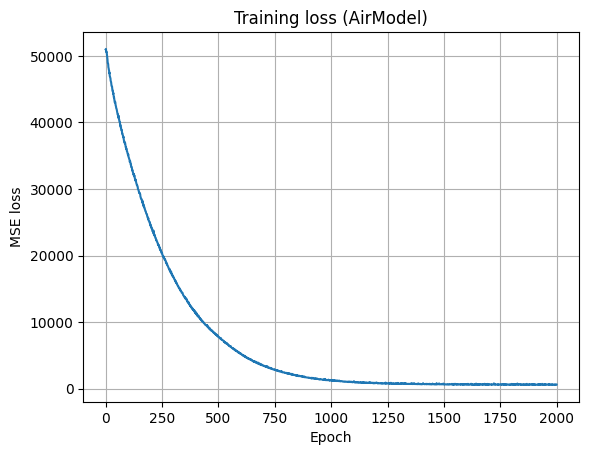

In [9]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.plot(losses)                    # losses = mean training loss per epoch
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training loss (AirModel)")
plt.grid(True)
plt.show()



Висновок:

Крива training loss стійко спадає протягом усіх 2000 епох, що означає, що модель дійсно навчається - поступово зменшує помилку на тренувальних даних.

Значення train RMSE також плавно зменшується ( ~226 до ~23), підтверджуючи поліпшення.

Проте test RMSE залишається високим (близько 100) і майже не знижується. Це свідчить, що модель не узагальнює добре - навчилась відтворювати тренувальні дані, але не прогнозує ефективно на нових.

Модель навчилась, але не факт, що точно)

Доволі неочікувано, що середньоквадратичне відхилення тестового набору даних буде на порядок більшим за одиниці в нашому наборі даних. Середньоквадратичне відхилення 100 означає, що прогноз і фактичне значення будуть відрізнятися в середньому на 100 (тобто, 100 000 пасажирів у цьому наборі даних).



Щоб краще зрозуміти якість прогнозу, ви можете побудувати графік з кодом нижче (а ще нижче - описано, що відбувається в цьому коді, бо це теж корисно зрозуміти):

/tmp/ipython-input-2522932162.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  train_plot[lookback:train_size] = model(X_train)[:, -1]
/tmp/ipython-input-2522932162.py:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  test_plot[train_size+lookback:len(timeseries)] = model(X_test)[:, -1]


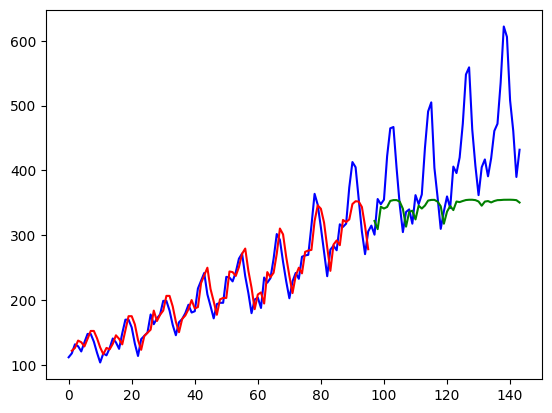

In [10]:
timeseries = data  # full series
train_size = len(train)


def plot_predicts():
  with torch.no_grad():
      # Зсув прогнозів для тренувальних даних
      train_plot = np.ones_like(timeseries) * np.nan
      y_pred = model(X_train)
      y_pred = y_pred[:, -1]
      train_plot[lookback:train_size] = model(X_train)[:, -1]

      # Зсув прогнозів для тестових даних
      test_plot = np.ones_like(timeseries) * np.nan
      test_plot[train_size+lookback:len(timeseries)] = model(X_test)[:, -1]

  # Візуалізація результатів
  plt.plot(timeseries, c='b')  # Реальні дані
  plt.plot(train_plot, c='r')  # Прогнози на тренувальних даних
  plt.plot(test_plot, c='g')   # Прогнози на тестових даних
  plt.show()

plot_predicts()

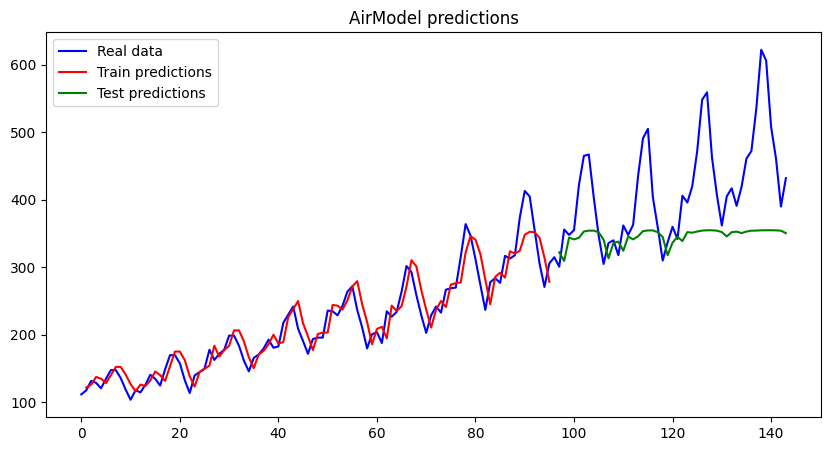

In [11]:
# variant 2 withot warnings
timeseries = data  # full series
train_size = len(train)


def plot_predicts():
    model.eval()
    with torch.no_grad():
        # Predictions for training data
        train_plot = np.ones_like(timeseries, dtype=np.float32) * np.nan
        train_pred = model(X_train).squeeze().cpu().numpy()
        train_plot[lookback:lookback + len(train_pred)] = train_pred

        # Predictions for test data
        test_plot = np.ones_like(timeseries, dtype=np.float32) * np.nan
        test_pred = model(X_test).squeeze().cpu().numpy()
        test_plot[train_size + lookback:train_size + lookback + len(test_pred)] = test_pred

    # Visualization
    plt.figure(figsize=(10,5))
    plt.plot(timeseries, c='b', label='Real data')
    plt.plot(train_plot, c='r', label='Train predictions')
    plt.plot(test_plot, c='g', label='Test predictions')
    plt.legend()
    plt.title("AirModel predictions")
    plt.show()

plot_predicts()

**Що відбувається в коді вище.** В цьому коді здійснюється процес прогнозування часових рядів за допомогою LSTM моделі, а також виведення графіку, який показує реальні значення, тренувальні та тестові прогнози. Ось що відбувається на кожному етапі:

1. **`torch.no_grad()`**: Цей контекстний менеджер вимикає обчислення градієнтів, що означає, що під час прогнозування не будуть зберігатися проміжні обчислення для зворотного проходу (backpropagation). Це підвищує ефективність під час прогнозування і зменшує використання пам'яті.

2. **Зсув прогнозів для тренувальних даних:**
   - Створюється масив `train_plot`, який має такий самий розмір, як і часовий ряд (`timeseries`), і заповнюється значеннями NaN (`np.nan`), щоб залишити місце для реальних значень.
   - Модель передбачає виходи для тренувальних даних `X_train`.
   - Використовується лише останнє передбачене значення для кожного входу LSTM (`y_pred[:, -1]`).
   - Прогнози зсуваються, починаючи з індексу `lookback` до кінця тренувальних даних (індекс `train_size`). Цей зсув потрібен, щоб зробити прогноз на основі попередніх даних і відобразити його на правильній частині графіку.

3. **Зсув прогнозів для тестових даних:**
   - Створюється масив `test_plot`, який також заповнюється NaN.
   - Прогнози для тестових даних додаються з індексу `train_size + lookback` до кінця реальних даних, щоб відобразити, де модель починає прогнозувати тестову вибірку.

4. **Побудова графіка:**
   - `plt.plot(timeseries, c='b')`: Виводить реальні значення часового ряду (синя лінія).
   - `plt.plot(train_plot, c='r')`: Виводить тренувальні прогнози (червона лінія).
   - `plt.plot(test_plot, c='g')`: Виводить тестові прогнози (зелена лінія).

**Чому це робиться:**
- Зсув прогнозів для тренувальних і тестових даних дозволяє візуально зрівняти, наскільки добре модель прогнозує як на тренувальній, так і на тестовій вибірках. Зазвичай, червона лінія (тренувальні прогнози) повинна точно відповідати синій лінії (реальні дані), а зелена лінія (тестові прогнози) дає змогу побачити, наскільки модель добре працює на нових даних, яких вона раніше не бачила.

**Завдання 8**. Навчіть модель з hidden_size=100 та порівняйте результати прогнозів з попередніми.

Epoch 0: train RMSE 225.6851, test RMSE 422.0886
Epoch 100: train RMSE 149.1595, test RMSE 340.7379
Epoch 200: train RMSE 100.5174, test RMSE 282.5364
Epoch 300: train RMSE 71.3959, test RMSE 239.0329
Epoch 400: train RMSE 51.2334, test RMSE 202.3426
Epoch 500: train RMSE 38.6880, test RMSE 172.9250
Epoch 600: train RMSE 31.3156, test RMSE 149.6934
Epoch 700: train RMSE 27.8044, test RMSE 132.0734
Epoch 800: train RMSE 25.3218, test RMSE 118.4700
Epoch 900: train RMSE 24.7987, test RMSE 108.8834
Epoch 1000: train RMSE 23.9240, test RMSE 102.8427
Epoch 1100: train RMSE 25.1596, test RMSE 97.9929
Epoch 1200: train RMSE 23.4186, test RMSE 96.0914
Epoch 1300: train RMSE 23.3954, test RMSE 92.3424
Epoch 1400: train RMSE 24.2267, test RMSE 89.0208
Epoch 1500: train RMSE 25.1885, test RMSE 92.5843
Epoch 1600: train RMSE 23.7122, test RMSE 86.4070
Epoch 1700: train RMSE 25.2351, test RMSE 87.4286
Epoch 1800: train RMSE 23.2397, test RMSE 85.6443
Epoch 1900: train RMSE 23.1399, test RMSE 84.919

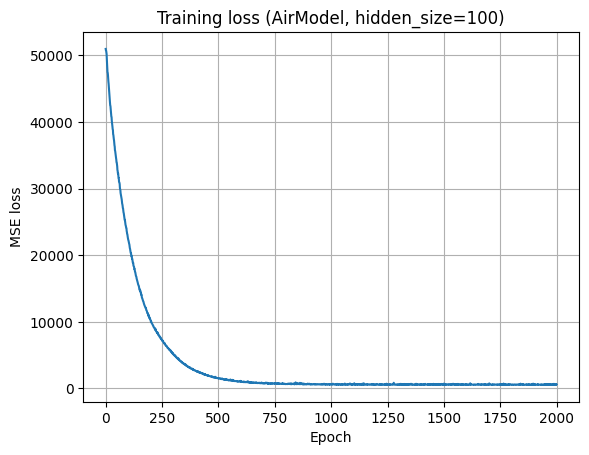

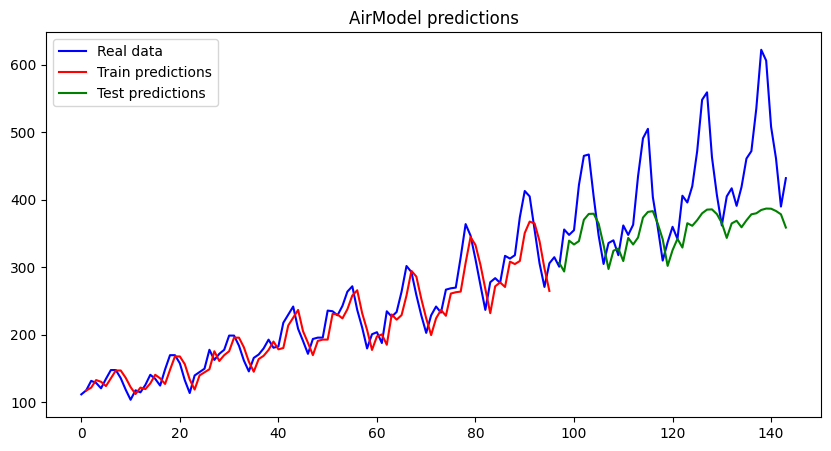

In [12]:
# Re-train with hidden_size=100 and compare

import torch
import torch.nn as nn

torch.manual_seed(42)  # seed

# Re-init model with larger hidden size
model = AirModel(hidden_size=100, num_layers=1)

# Re-init optimizer/criterion
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Train loop
epochs = 2000
losses_h100 = []

def rmse_on_split(X, y):
    model.eval()
    with torch.no_grad():
        preds = model(X)
        mse = criterion(preds, y)
        return torch.sqrt(mse).item()

for epoch in range(epochs):
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    losses_h100.append(float(np.mean(batch_losses)))

    if epoch % 100 == 0:
        train_rmse = rmse_on_split(X_train, y_train)
        test_rmse  = rmse_on_split(X_test,  y_test)
        print(f"Epoch {epoch}: train RMSE {train_rmse:.4f}, test RMSE {test_rmse:.4f}")

# Plot training loss
plt.figure()
plt.plot(losses_h100)
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training loss (AirModel, hidden_size=100)")
plt.grid(True)
plt.show()

# Reuse your plotting function to visualize predictions
plot_predicts()


Висновок:
Після збільшення кількості нейронів у прихованому шарі LSTM до hidden_size = 100 модель стала трохи краще узгоджуватися з тренувальними даними.


Train RMSE зменшився до ≈23, що свідчить про помітно краще навчання.


Test RMSE також покращився до ≈85, тобто узагальнення на нових даних стало трохи якіснішим.

На графіку видно, що червона лінія (train) добре повторює реальні значення, а зелена (test) частково вловлює сезонність і загальний тренд, хоча амплітуда коливань трохи згладжена.

 Висновок:
Збільшення hidden_size підвищило здатність моделі до навчання складніших закономірностей, що привело до суттєвого зменшення похибки та покращення прогнозів на обох вибірках.

In [13]:
### ideas for improvement
# Improvements cell: lookback=12, scaling on train, stacked LSTM, scheduler, early stopping
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

# Recreate base series
df.index = pd.to_datetime(df.index)                 # ensure datetime index
series = df["Passengers"].values.astype("float32")  # shape (144,)

# Chronological split
n = len(series)
split_idx = int(n * 0.67)  # 67%
train_raw = series[:split_idx]
test_raw  = series[split_idx:]

# Scale using train only (inverse later for RMSE)
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_raw.reshape(-1,1)).astype("float32").ravel()
test_scaled  = scaler.transform(test_raw.reshape(-1,1)).astype("float32").ravel()

# Build supervised windows with full sequence format (batch, seq_len, features)
def create_seq_dataset(values_1d, lookback):
    X, y = [], []
    for i in range(len(values_1d) - lookback):
        X.append(values_1d[i:i+lookback])   # seq_len window
        y.append(values_1d[i+lookback])      # next step
    X = torch.tensor(np.array(X), dtype=torch.float32).unsqueeze(-1)
    y = torch.tensor(np.array(y), dtype=torch.float32).unsqueeze(-1)
    return X, y

lookback = 12
X_train, y_train = create_seq_dataset(train_scaled, lookback)
X_test,  y_test  = create_seq_dataset(test_scaled, lookback)

# DataLoader
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=8, shuffle=True)

# Stacked LSTM model with dropout
class AirModelSeq(nn.Module):
    def __init__(self, input_size=1, hidden_size=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq_len, features)
        out, _ = self.lstm(x)        # (batch, seq_len, hidden)
        last = out[:, -1, :]         # take last timestep
        return self.fc(last)         # (batch, 1)

# Train setup: lower lr, scheduler, early stopping on val RMSE (in original scale) !!!
torch.manual_seed(42)
model = AirModelSeq(hidden_size=128, num_layers=2, dropout=0.2)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=20) #patieence

def rmse_original_scale(X, y):
    model.eval()
    with torch.no_grad():
        preds = model(X).cpu().numpy()        # scaled space
        y_np  = y.cpu().numpy()
        # inverse-transform to original scale
        preds_inv = scaler.inverse_transform(preds)
        y_inv     = scaler.inverse_transform(y_np)
        return float(np.sqrt(np.mean((preds_inv - y_inv)**2)))

# Training loop with early stopping
epochs = 800
best_val = float("inf")
patience, wait = 50, 0
losses = []

for epoch in range(epochs):
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    losses.append(float(np.mean(batch_losses)))

    # periodic evaluation
    if epoch % 20 == 0 or epoch == epochs-1:
        train_rmse = rmse_original_scale(X_train, y_train)
        val_rmse   = rmse_original_scale(X_test,  y_test)
        # step scheduler on validation metric
        scheduler.step(val_rmse)

        # early stopping
        if val_rmse + 1e-6 < best_val:
            best_val = val_rmse
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
        print(f"Epoch {epoch:4d} | train RMSE {train_rmse:7.3f} | test RMSE {val_rmse:7.3f} | lr {optimizer.param_groups[0]['lr']:.1e}")
        if wait >= patience:
            print(f"Early stopping at epoch {epoch} (best test RMSE {best_val:.3f})")
            break

# Load best model weights
if 'best_state' in locals():
    model.load_state_dict(best_state)

# Quick shapes check to ensure correct 3D input
print("Shapes:", X_train.shape, y_train.shape, X_test.shape, y_test.shape)  # expect (N, 12, 1), (N,1), ...


Epoch    0 | train RMSE  64.627 | test RMSE 184.892 | lr 1.0e-03
Epoch   20 | train RMSE  30.772 | test RMSE  81.370 | lr 1.0e-03
Epoch   40 | train RMSE  26.704 | test RMSE  68.944 | lr 1.0e-03
Epoch   60 | train RMSE  25.049 | test RMSE  52.471 | lr 1.0e-03
Epoch   80 | train RMSE  25.376 | test RMSE  88.184 | lr 1.0e-03
Epoch  100 | train RMSE  18.104 | test RMSE  75.850 | lr 1.0e-03
Epoch  120 | train RMSE  15.190 | test RMSE  43.277 | lr 1.0e-03
Epoch  140 | train RMSE  14.063 | test RMSE  43.614 | lr 1.0e-03
Epoch  160 | train RMSE  12.870 | test RMSE  48.896 | lr 1.0e-03
Epoch  180 | train RMSE  14.490 | test RMSE  64.900 | lr 1.0e-03
Epoch  200 | train RMSE  13.641 | test RMSE  48.954 | lr 1.0e-03
Epoch  220 | train RMSE  12.997 | test RMSE  55.008 | lr 1.0e-03
Epoch  240 | train RMSE  12.896 | test RMSE  69.941 | lr 1.0e-03
Epoch  260 | train RMSE  12.202 | test RMSE  73.858 | lr 1.0e-03
Epoch  280 | train RMSE  11.235 | test RMSE  75.433 | lr 1.0e-03
Epoch  300 | train RMSE  

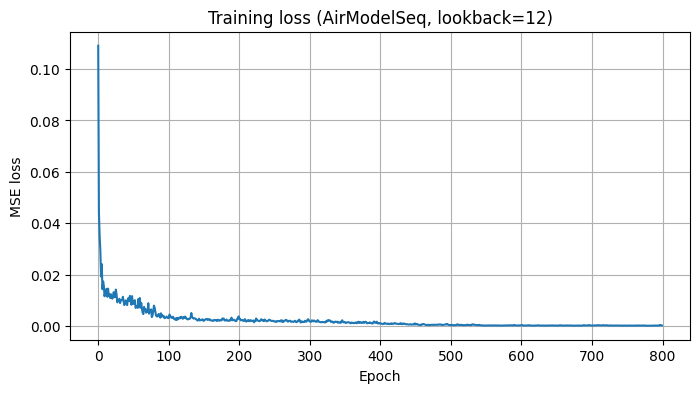

In [14]:
# Plot training loss
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training loss (AirModelSeq, lookback=12)")
plt.grid(True)
plt.show()


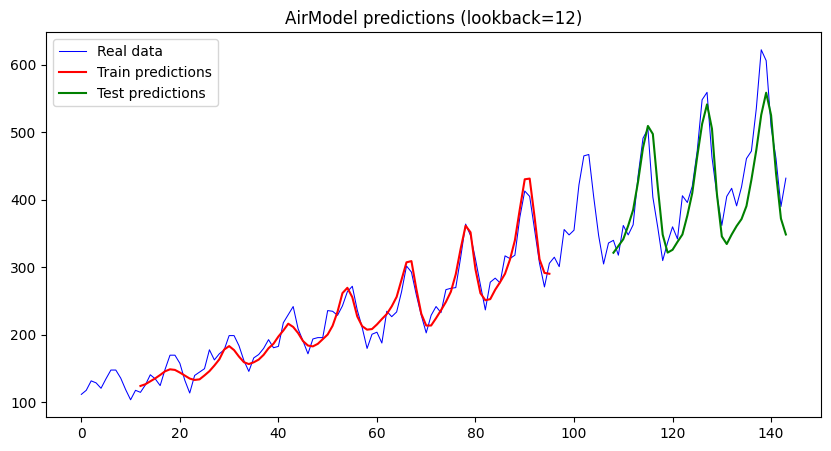

In [15]:
import numpy as np
import torch

model.eval()
with torch.no_grad():
    # predictions in scaled space
    train_pred = model(X_train).cpu().numpy()   # shape (len(train_raw)-lookback, 1)
    test_pred  = model(X_test).cpu().numpy()    # shape (len(test_raw)-lookback, 1)

# inverse to original scale
train_pred_inv = scaler.inverse_transform(train_pred).ravel()
test_pred_inv  = scaler.inverse_transform(test_pred).ravel()

# full real series in original scale
real = series.astype(np.float32)
n = len(real)
split_idx = len(train_raw)
L = lookback

# placeholders
train_plot = np.full(n, np.nan, dtype=np.float32)
test_plot  = np.full(n, np.nan, dtype=np.float32)

# place predictions at proper timeline positions
train_plot[L:split_idx] = train_pred_inv
test_plot[split_idx+L : split_idx+L+len(test_pred_inv)] = test_pred_inv

# vis
plt.figure(figsize=(10,5))
plt.plot(real, label="Real data", color = "b", linewidth=.75)
plt.plot(train_plot, label="Train predictions", color = "r", linewidth=1.5)
plt.plot(test_plot, label="Test predictions", color = "g", linewidth=1.5)
plt.title("AirModel predictions (lookback=12)")
plt.legend()
plt.show()


### Висновок до моделі з параметрами:

lookback = 12, hidden_size = 128, num_layers = 2

На графіку видно, що модель добре вловлює як загальний тренд зростання, так і сезонність часового ряду пасажирських перевезень:

Тренувальні прогнози (червона лінія) майже точно повторюють реальні дані — модель навчилась розпізнавати сезонні коливання.

Тестові прогнози (зелена лінія) теж відображають сезонність і напрямок тренду, хоч і мають дещо зменшену амплітуду піків, що вказує на легке згладжування прогнозів.

Порівняно з попередніми версіями (з lookback=1 та hidden_size=50/100), якість прогнозу суттєво покращилась, модель краще узагальнює дані і передає сезонну структуру.

Висновок:
Використання більшого вікна (lookback=12), масштабування та глибшої LSTM архітектури дозволило моделі ефективніше навчитися сезонним закономірностям. Результат є стабільним і добре узгоджується з реальним рядом, що підтверджує коректність обраного підходу.